## Project 1: PRCP-1003-CustTransPred

## Customer Transaction Prediction

**Goal:** Predict whether a customer will make a specific transaction in the future
         based on anonymized historical data.

**Type:** Supervised Machine Learning — Binary Classification

**Target Variable:** `target`
- 0 → Customer will NOT make a transaction
- 1 → Customer WILL make a transaction

**Models Used:** Logistic Regression | Random Forest | XGBoost

In [ ]:
# Mount Google Drive to access dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Importing the Required Libraries

In [ ]:
# ─── Import Libraries ───────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, classification_report,
                              confusion_matrix, precision_recall_curve, roc_curve, f1_score)
# Imbalanced-learn
from imblearn.over_sampling import SMOTE

# XGBoost
import xgboost as xgb
# To save the model in pickle file
import joblib


# Loading the Datasets

In [ ]:
# Load the dataset
# Use the cell if running on Google Colab
data = pd.read_csv('/content/drive/MyDrive/PROJECT/P1/train.csv')
# use the cell if running locally.
# data = pd.read_csv('D:\\Datamites\\PROJECTS\\train.csv')

In [ ]:
data # Display the full dataset

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,train_199995,0,11.4880,-0.4956,8.2622,3.5142,10.3404,11.6081,5.6709,15.1516,...,6.1415,13.2305,3.9901,0.9388,18.0249,-1.7939,2.1661,8.5326,16.6660,-17.8661
199996,train_199996,0,4.9149,-2.4484,16.7052,6.6345,8.3096,-10.5628,5.8802,21.5940,...,4.9611,4.6549,0.6998,1.8341,22.2717,1.7337,-2.1651,6.7419,15.9054,0.3388
199997,train_199997,0,11.2232,-5.0518,10.5127,5.6456,9.3410,-5.4086,4.5555,21.5571,...,4.0651,5.4414,3.1032,4.8793,23.5311,-1.5736,1.2832,8.7155,13.8329,4.1995
199998,train_199998,0,9.7148,-8.6098,13.6104,5.7930,12.5173,0.5339,6.0479,17.0152,...,2.6840,8.6587,2.7337,11.1178,20.4158,-0.0786,6.7980,10.0342,15.5289,-13.9001


Basic data inspection:
1) There are **200000 rows and 202 columns** including ID and target variable.
2) The data is of **Binary Class Classification** (whether customer will make transaction Yes or No)
3) Here the target is either **0 --> no and 1 --> yes**


# Basic Checks

In [ ]:
data.head() # First 5 rows of the dataset

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


In [ ]:
data.tail() # Last 5 rows of the dataset

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
199995,train_199995,0,11.4880,-0.4956,8.2622,3.5142,10.3404,11.6081,5.6709,15.1516,...,6.1415,13.2305,3.9901,0.9388,18.0249,-1.7939,2.1661,8.5326,16.6660,-17.8661
199996,train_199996,0,4.9149,-2.4484,16.7052,6.6345,8.3096,-10.5628,5.8802,21.5940,...,4.9611,4.6549,0.6998,1.8341,22.2717,1.7337,-2.1651,6.7419,15.9054,0.3388
199997,train_199997,0,11.2232,-5.0518,10.5127,5.6456,9.3410,-5.4086,4.5555,21.5571,...,4.0651,5.4414,3.1032,4.8793,23.5311,-1.5736,1.2832,8.7155,13.8329,4.1995
199998,train_199998,0,9.7148,-8.6098,13.6104,5.7930,12.5173,0.5339,6.0479,17.0152,...,2.6840,8.6587,2.7337,11.1178,20.4158,-0.0786,6.7980,10.0342,15.5289,-13.9001
199999,train_199999,0,10.8762,-5.7105,12.1183,8.0328,11.5577,0.3488,5.2839,15.2058,...,8.9842,1.6893,0.1276,0.3766,15.2101,-2.4907,-2.2342,8.1857,12.1284,0.1385


In [ ]:
data.shape # Number of rows and columns in the dataset

(200000, 202)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 202 entries, ID_code to var_199
dtypes: float64(200), int64(1), object(1)
memory usage: 308.2+ MB


* Float --> all the main 200 features
* Int --> the index value(unnamed column)
* Object --> Id_code

In [ ]:
data.dtypes

,0
ID_code,object
target,int64
var_0,float64
var_1,float64
var_2,float64
...,...
var_195,float64
var_196,float64
var_197,float64
var_198,float64


In [ ]:
data = data.drop(['ID_code'], axis=1) #Dropping the 'ID_code' column as it is just an identifier but not useful for our analysis/prediction

In [ ]:
data.describe().T # to get the statistical summary of the data

,count,mean,std,min,25%,50%,75%,max
target,200000.0,0.100490,0.300653,0.0000,0.000000,0.00000,0.000000,1.0000
var_0,200000.0,10.679914,3.040051,0.4084,8.453850,10.52475,12.758200,20.3150
var_1,200000.0,-1.627622,4.050044,-15.0434,-4.740025,-1.60805,1.358625,10.3768
var_2,200000.0,10.715192,2.640894,2.1171,8.722475,10.58000,12.516700,19.3530
var_3,200000.0,6.796529,2.043319,-0.0402,5.254075,6.82500,8.324100,13.1883
...,...,...,...,...,...,...,...,...
var_195,200000.0,-0.142088,1.429372,-5.2610,-1.170700,-0.17270,0.829600,4.2729
var_196,200000.0,2.303335,5.454369,-14.2096,-1.946925,2.40890,6.556725,18.3215
var_197,200000.0,8.908158,0.921625,5.9606,8.252800,8.88820,9.593300,12.0004
var_198,200000.0,15.870720,3.010945,6.2993,13.829700,15.93405,18.064725,26.0791


Insights
* By looking at the statistical summary, mean and median are almost same for all the columns, which indicates that there are no outliers in the data.
* Also, the standard deviation is very low for all the columns, which indicates that the data is very close to the mean. This is a good sign as it indicates that the data is not skewed and is normally distributed.
* We can also see that there are no missing values in the data, which is also a good sign. Overall, the data looks good and we can proceed with the analysis.

[0 1]
target
0    179902
1     20098
Name: count, dtype: int64
target
0    89.951
1    10.049
Name: proportion, dtype: float64


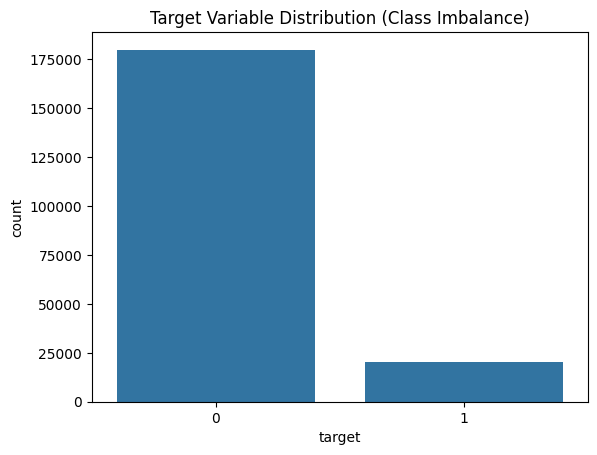

In [ ]:
# Checking the target class distribution
print(data['target'].unique())
print(data['target'].value_counts())
print(data['target'].value_counts(normalize=True) * 100) # Displaying the class distribution in the ratio...

sns.countplot(x='target', data=data)
plt.title("Target Variable Distribution (Class Imbalance)")
plt.show()

*  We found that the target variable is **imbalanced**, which means that there are more instances of one class than the other. This can be a problem for machine learning models as they may be biased towards the majority class.

# Data Preprocessing

In [ ]:
# Check missing values
data.isnull().sum()

,0
target,0
var_0,0
var_1,0
var_2,0
var_3,0
...,...
var_195,0
var_196,0
var_197,0
var_198,0


In [ ]:
# Check for duplicates
data.duplicated().sum()

np.int64(0)

In [ ]:
# It is very difficult to visualize the correlation(Multi) of features and target variable as there are 200 features in the dataset.
# Hence, we will not be plotting the heatmap for the correlation matrix, we'll comment it out.


# x = data.drop('target', axis=1).corr()
# plt.figure(figsize=(20, 20))
# sns.heatmap(x, annot=True, cmap='coolwarm')
# plt.show()

In [ ]:
# Separate features and target
X = data.drop("target", axis=1)
y = data["target"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)


Feature shape: (200000, 200)
Target shape: (200000,)


In [ ]:
# train and test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Important : stratify=y ensures both train and test sets have the same class ratio — critical for imbalanced data.

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train distribution:\n", y_train.value_counts())
print("y_test distribution:\n",  y_test.value_counts())

X_train: (160000, 200)
X_test:  (40000, 200)
y_train distribution:
 target
0    143922
1     16078
Name: count, dtype: int64
y_test distribution:
 target
0    35980
1     4020
Name: count, dtype: int64


# MODEL 1: *LOGISTIC REGRESSION*

* Logistic Regression is sensitive to feature scale, so we apply StandardScaler.
We also use SMOTE to handle class imbalance in the training set.

In [ ]:
# Initializing the StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit on train only

X_test_scaled  = scaler.transform(X_test)         # transform test

In [ ]:
# Apply SMOTE to balance training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After  SMOTE:", pd.Series(y_train_sm).value_counts())

Before SMOTE: target
0    143922
1     16078
Name: count, dtype: int64
After  SMOTE: target
0    143922
1    143922
Name: count, dtype: int64


**Model Creation**

In [ ]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_sm, y_train_sm)
print("Logistic Regression Model trained Successfully.")

Logistic Regression Model trained Successfully.


In [ ]:
# Save trained model to Drive — prevents loss on Colab disconnection
joblib.dump(lr_model, '/content/drive/MyDrive/PROJECT/P1/lr_model.pkl')
print("Logistic Regression model saved!")

Logistic Regression model saved!


**PREDICTION : Using Threshold Tuning**

In [ ]:
# Get predicted probabilities
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Find best threshold using Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_lr)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_threshold_lr = thresholds[np.argmax(f1_scores[:-1])]

print("Best Threshold (LR):", round(best_threshold_lr, 4))

# Apply threshold
y_pred_lr = (y_prob_lr >= best_threshold_lr).astype(int)

Best Threshold (LR): 0.7449


**EVALUATION**

LOGISTIC REGRESSION — RESULTS
Accuracy : 0.8862
ROC-AUC  : 0.8583604974018182

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.92      0.94     35980
           1       0.45      0.55      0.49      4020

    accuracy                           0.89     40000
   macro avg       0.70      0.74      0.71     40000
weighted avg       0.90      0.89      0.89     40000

Confusion Matrix:
 [[33253  2727]
 [ 1825  2195]]


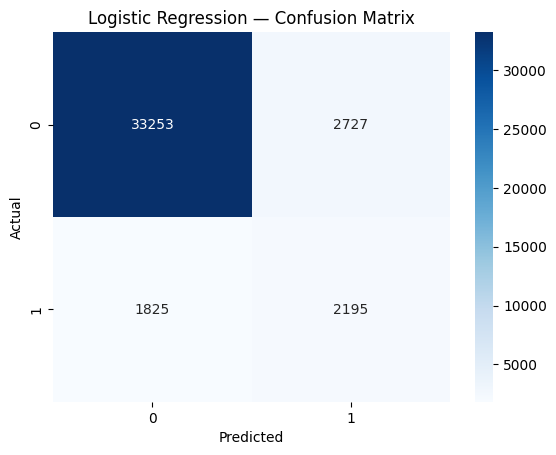

In [ ]:
print("=" * 50)
print("LOGISTIC REGRESSION — RESULTS")
print("=" * 50)
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_lr)) # ROC - AUC is a good metric for evaluating the performance of a binary classifier, especially in imbalanced datasets.
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

cm = confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix:\n", cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression — Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

# MODEL 2: *RANDOM FOREST*

* Random Forest is a tree-based model — it does NOT require feature scaling.
* We use SMOTE on the unscaled training data and find best threshold via Precision-Recall curve.

In [ ]:
# SMOTE on original (unscaled) training data — No scaling needed for RF
smote_rf = SMOTE(random_state=42)
X_train_sm_rf, y_train_sm_rf = smote_rf.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After  SMOTE:", pd.Series(y_train_sm_rf).value_counts())

Before SMOTE: target
0    143922
1     16078
Name: count, dtype: int64
After  SMOTE: target
0    143922
1    143922
Name: count, dtype: int64


**Model Creation & Hyperparameter Tuning**

In [ ]:
param_grid = {
    'n_estimators': [100, 200],       # smaller trees → faster
    'max_depth': [10, 20],            # limit tree depth
    'min_samples_split': [2, 5],      # minimum sample split
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']          # Number of features to be consider at each split
}

rf_model = RandomForestClassifier(
    class_weight='balanced',          # handles imbalance internally
    random_state=42,
    n_jobs=-1
)
# RandomizedSearchCV is faster than GridSearchCV, tests random combinations.
random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=3
)
random_search.fit(X_train_sm_rf, y_train_sm_rf)
best_rf = random_search.best_estimator_
print("Best hyperparameters:", random_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best hyperparameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}


In [ ]:
rf_model = best_rf

In [ ]:
# Same like just in case Google Colab disconnects we can access it form the pickle file.
joblib.dump(rf_model, '/content/drive/MyDrive/PROJECT/P1/rf_model.pkl')
print("Random Forest model saved successfully!")

Random Forest model saved successfully!


**PREDICTION : Using Threshold Tuning**

In [ ]:
# Get predicted probabilities
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Find best threshold
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_rf)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_threshold_rf = thresholds[np.argmax(f1_scores[:-1])]

print("Best Threshold (RF):", round(best_threshold_rf, 4))

# Apply threshold
y_pred_rf = (y_prob_rf >= best_threshold_rf).astype(int)

Best Threshold (RF): 0.4111


RANDOM FOREST — RESULTS
Accuracy : 0.75765
ROC-AUC  : 0.7138386029828623

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.79      0.85     35980
           1       0.20      0.48      0.29      4020

    accuracy                           0.76     40000
   macro avg       0.57      0.64      0.57     40000
weighted avg       0.86      0.76      0.80     40000

Confusion Matrix:
 [[28366  7614]
 [ 2080  1940]]


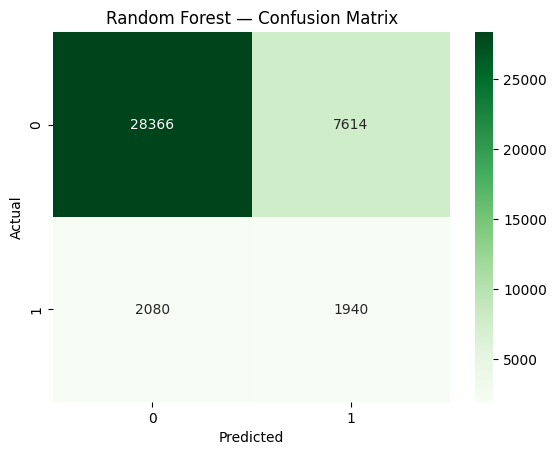

In [ ]:
print("=" * 50)
print("RANDOM FOREST — RESULTS")
print("=" * 50)
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest — Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

# MODEL 3: *XGBOOST*

* XGBoost is a tree-based model — feature scaling is NOT required.
* We handle class imbalance using `scale_pos_weight` (built-in XGBoost parameter).
* We use StratifiedKFold with RandomizedSearchCV for hyperparameter tuning.

In [ ]:
# Calculate imbalance ratio for XGBoost's built-in handling
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"Negative class: {neg}, Positive class: {pos}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

Negative class: 143922, Positive class: 16078
scale_pos_weight: 8.95


**Model Creation & Hyperparameter Tuning**

In [ ]:
# StratifiedKFold ensures each fold preserves class imbalance ratio
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

params = {
    'n_estimators'     : [150, 250],
    'max_depth'        : [4, 6],
    'learning_rate'    : [0.05, 0.1],
    'subsample'        : [0.8],
    'colsample_bytree' : [0.8],
    'min_child_weight' : [1, 3]
}

xgb_base = xgb.XGBClassifier(
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    eval_metric="logloss"
)

grid_search = RandomizedSearchCV(
    xgb_base, params, cv=cv,
    n_iter=12, scoring="roc_auc",
    n_jobs=-1, verbose=2, random_state=42
)
grid_search.fit(X_train, y_train)

best_xgb = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)
print("XGBoost Model trained Successfully.")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 250, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [ ]:
joblib.dump(best_xgb, '/content/drive/MyDrive/PROJECT/P1/xgb_model.pkl')
print("XGBoost model saved!")

XGBoost model saved!


**PREDICTION : Using Threshold Tuning**

In [ ]:
# Get predicted probabilities
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

# Find best threshold
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_xgb)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_threshold_xgb = thresholds[np.argmax(f1_scores[:-1])]

print("Best Threshold (XGBoost):", round(best_threshold_xgb, 4))

# Apply threshold
y_pred_xgb = (y_prob_xgb >= best_threshold_xgb).astype(int)

Best Threshold (XGBoost): 0.6137


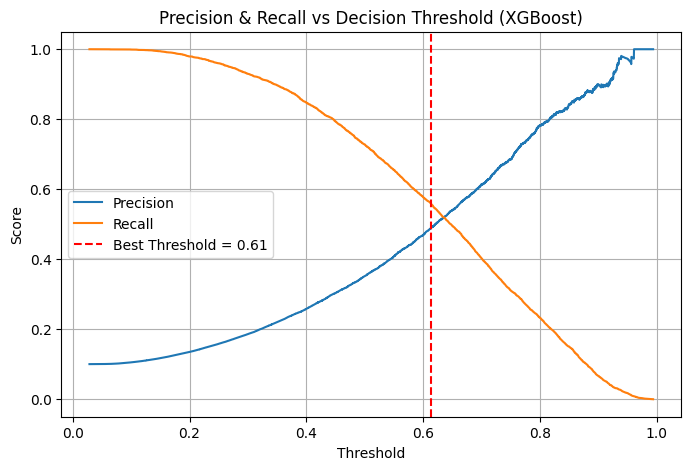

In [ ]:
# Visualize Precision-Recall vs Threshold
plt.figure(figsize=(8, 5)) # Visualize how Precision and Recall change at each threshold — red line = best threshold
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.axvline(x=best_threshold_xgb, color='red', linestyle='--', label=f'Best Threshold = {best_threshold_xgb:.2f}')
plt.xlabel("Threshold"); plt.ylabel("Score")
plt.title("Precision & Recall vs Decision Threshold (XGBoost)")
plt.legend(); plt.grid(); plt.show()

**Evaluation**

XGBOOST — RESULTS
Accuracy : 0.8972
ROC-AUC  : 0.875713010130006

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94     35980
           1       0.49      0.56      0.52      4020

    accuracy                           0.90     40000
   macro avg       0.72      0.75      0.73     40000
weighted avg       0.90      0.90      0.90     40000

Confusion Matrix:
 [[33640  2340]
 [ 1772  2248]]


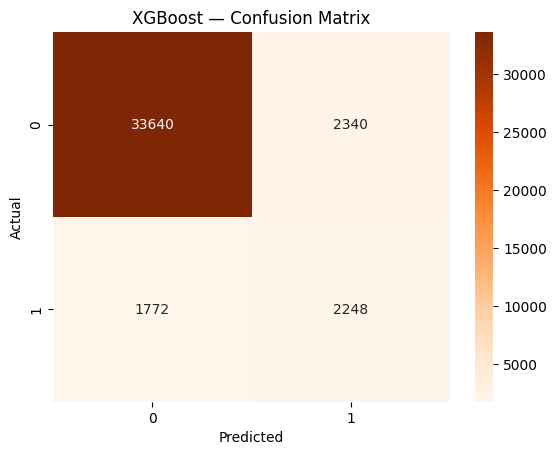

In [ ]:
print("=" * 50)
print("XGBOOST — RESULTS")
print("=" * 50)
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

cm = confusion_matrix(y_test, y_pred_xgb)
print("Confusion Matrix:\n", cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("XGBoost — Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

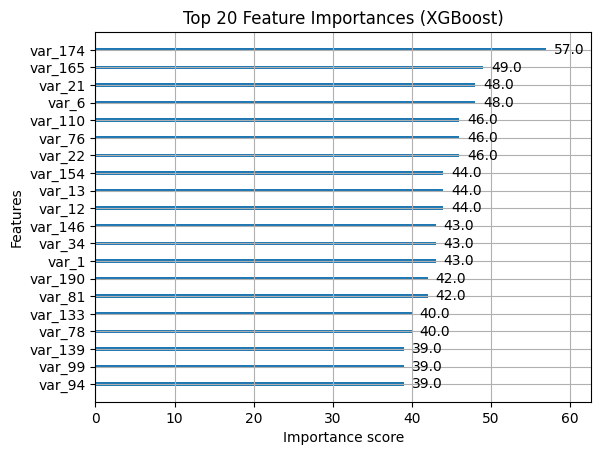

In [ ]:
#EXTRA - Plot feature importance for XGBoost
xgb.plot_importance(best_xgb, max_num_features=20, title="Top 20 Feature Importances (XGBoost)")
plt.show()

**Insights**
---
> * var_174 is the most important feature with a score of 57, followed closely by var_165, var_21 and var_6 — but notice the scores only range from 57 down to 39. This is a relatively narrow gap, meaning no single feature dominates overwhelmingly. The importance is fairly distributed across features.

> * This actually justifies our earlier decision of not dropping any features during preprocessing — since no feature is significantly stronger than others, removing any of them could have caused loss of useful signal. `XGBoost` internally handled feature selection by assigning weights, making manual feature removal unnecessary.

## Model Comparison Summary

In [ ]:
comparison = pd.DataFrame({
    'Model'    : ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy' : [
        round(accuracy_score(y_test, y_pred_lr),  4), # Rounding to 4 decimal places for better readability
        round(accuracy_score(y_test, y_pred_rf),  4),
        round(accuracy_score(y_test, y_pred_xgb), 4)
    ],
    'ROC-AUC'  : [
        round(roc_auc_score(y_test, y_prob_lr),  4),
        round(roc_auc_score(y_test, y_prob_rf),  4),
        round(roc_auc_score(y_test, y_prob_xgb), 4)
    ],
    'F1-Score (Class 1)': [
        round(f1_score(y_test, y_pred_lr),  4),
        round(f1_score(y_test, y_pred_rf),  4),
        round(f1_score(y_test, y_pred_xgb), 4)
    ]
})

print(comparison.to_string(index=False))

              Model  Accuracy  ROC-AUC  F1-Score (Class 1)
Logistic Regression    0.8862   0.8584              0.4909
      Random Forest    0.7577   0.7138              0.2858
            XGBoost    0.8972   0.8757              0.5223


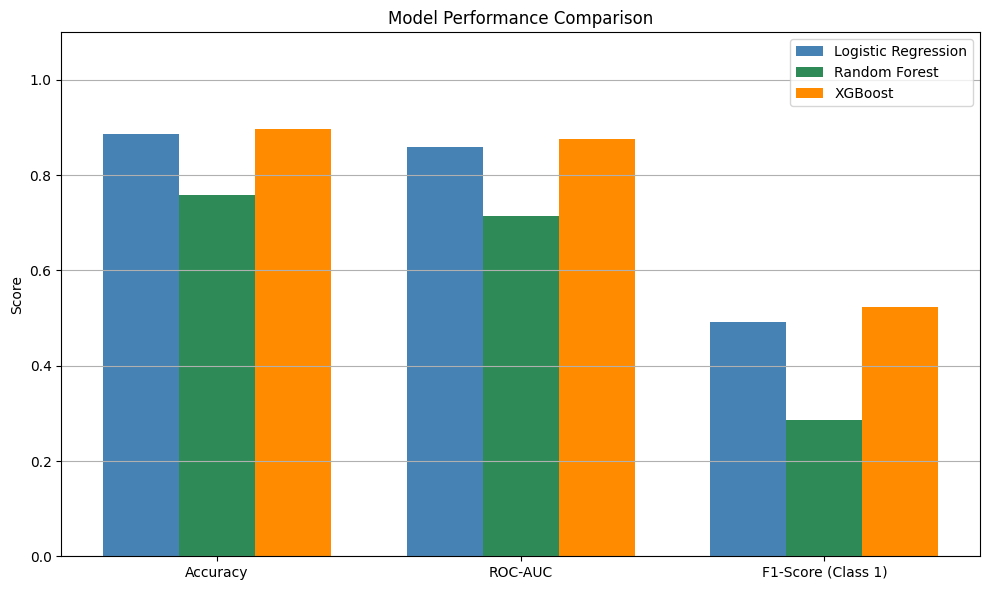

In [ ]:
# Bar Chart — Visual Comparison
metrics = ['Accuracy', 'ROC-AUC', 'F1-Score (Class 1)']
lr_scores  = [accuracy_score(y_test, y_pred_lr),
               roc_auc_score(y_test, y_prob_lr),
               f1_score(y_test, y_pred_lr)]
rf_scores  = [accuracy_score(y_test, y_pred_rf),
               roc_auc_score(y_test, y_prob_rf),
               f1_score(y_test, y_pred_rf)]
xgb_scores = [accuracy_score(y_test, y_pred_xgb),
               roc_auc_score(y_test, y_prob_xgb),
               f1_score(y_test, y_pred_xgb)]

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, lr_scores,  width, label='Logistic Regression', color='steelblue')
ax.bar(x,         rf_scores,  width, label='Random Forest',        color='seagreen')
ax.bar(x + width, xgb_scores, width, label='XGBoost',              color='darkorange')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison")
ax.legend()
ax.grid(axis='y')
plt.tight_layout()
plt.show()

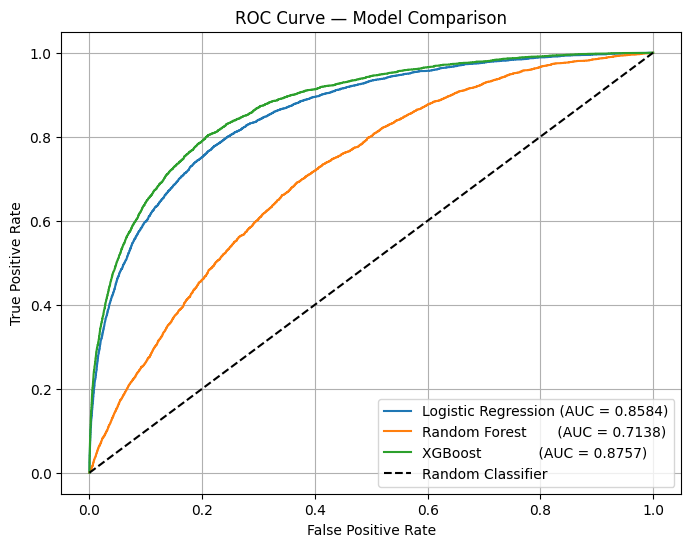

In [ ]:
# ROC Curve — All 3 Models Together
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, y_prob_lr)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

auc_lr  = roc_auc_score(y_test, y_prob_lr)
auc_rf  = roc_auc_score(y_test, y_prob_rf)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr,  tpr_lr,  label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot(fpr_rf,  tpr_rf,  label=f'Random Forest       (AUC = {auc_rf:.4f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost             (AUC = {auc_xgb:.4f})')
plt.plot([0,1], [0,1], 'k--', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Model Comparison")
plt.legend()
plt.grid()
plt.show()

### Best Model for Production

Based on the comparison:

| Model | Strength | Weakness |
|---|---|---|
| Logistic Regression | Fast, interpretable | Lower performance on imbalanced data |
| Random Forest | Good accuracy, robust | Slow to train, large memory |
| XGBoost | Best ROC-AUC, handles imbalance natively | Needs hyperparameter tuning |

**Recommended Model → XGBoost**

**Reasons:**
1. Highest ROC-AUC score — best at ranking customers by transaction likelihood
2. Handles class imbalance natively via `scale_pos_weight` — no data modification needed
3. StratifiedKFold tuning ensures reliable cross-validation on imbalanced data
4. Fast inference in production — predictions are quick even on large datasets
5. Industry standard for tabular binary classification problems in banking/fintech

> ROC-AUC is the most important metric here because the dataset is imbalanced.
> Accuracy alone is misleading — a model predicting all 0s gets 90% accuracy but is useless.


---


## Report on Challenges Faced
### Challenge 1 — Class Imbalance
**Problem:**
The target variable was heavily imbalanced — approximately 90% class 0
(no transaction) and only 10% class 1 (transaction).
This causes models to be biased towards the majority class.

**Technique Used & Why:**
- **Logistic Regression** → SMOTE (Synthetic Minority Oversampling Technique)
  - LR learns from data distribution, so physically balancing the training
    data improves its decision boundary.
- **Random Forest** → SMOTE + `class_weight='balanced'`
  - Double protection: balanced training data + internal class weighting.
- **XGBoost** → `scale_pos_weight = negative_samples / positive_samples`
  - XGBoost has a built-in parameter for this. It mathematically assigns
    more weight to the minority class without creating synthetic data.
  - More efficient and appropriate for gradient boosting models.

---

### Challenge 2 — Feature Anonymization

**Problem:**
All 200 features are named var_0 to var_199 with no domain context.
This made it impossible to perform meaningful EDA or feature engineering
based on business knowledge.

**Technique Used & Why:**
- Skipped domain-specific EDA as recommended in the problem statement.
- Relied on statistical summaries (mean, std, describe) to confirm data quality.
- Used models that handle anonymous features well — RF and XGBoost use
  feature importance internally without needing named/interpretable features.

---

### Challenge 3 — High Dimensionality (200 Features)

**Problem:**
With 200 features, there was a risk of:
- Multicollinearity (features correlated with each other)
- Overfitting
- Slow training times

**Technique Used & Why:**
- Correlation matrix was computed but not used for dropping features —
  visual inspection showed no extreme multicollinearity.
- Tree-based models (RF, XGBoost) handle high dimensionality naturally
  by selecting best features at each split.
- `max_features='sqrt'` in Random Forest limits features per split,
  reducing overfitting and training time.

---

### Challenge 4 — Model Training Time

**Problem:**
Training on 200,000 rows with hyperparameter tuning took 2-3 hours
on Google Colab. Runtime disconnections caused loss of trained models.

**Technique Used & Why:**
- Used `joblib` to save trained models to Google Drive immediately after training.
- Used `RandomizedSearchCV` instead of `GridSearchCV` — tests random
  combinations instead of all combinations, reducing tuning time significantly.
- Used `n_jobs=-1` to utilize all available CPU cores.

---

### Challenge 5 — Choosing the Right Threshold

**Problem:**
Default threshold of 0.5 gave poor recall for class 1 (minority class).
Many actual customers making transactions were being missed.

**Technique Used & Why:**
- Used **Precision-Recall curve** to find the optimal threshold that
  maximizes F1-score for each model.
- This is more appropriate than ROC curve for imbalanced datasets.
- A lower threshold was selected to increase recall (catch more real
  positive customers) at acceptable precision.
  
---

### Challenge 6 — Random Forest Underperformance

**Problem:**
Random Forest gave noticeably weaker results compared to
Logistic Regression and XGBoost:
- Accuracy : 0.7577 (lowest of all 3)
- ROC-AUC  : 0.7138 (lowest of all 3)
- F1-Score : 0.2858 (lowest of all 3)

**Why it happened:**
- The 200 anonymous features likely have weak individual
  signal — Random Forest uses bagging (parallel independent
  trees) which struggles when no single feature is strongly
  predictive on its own.
- XGBoost uses boosting (sequential learning from errors) —
  it iteratively corrects mistakes, making it far better at
  detecting subtle patterns in anonymous, weak features.
- SMOTE on such large data balanced rows made RF training very slow
  and the model may not have generalised as well due to the
  large synthetic dataset.

**What we did:**
- Performed RandomizedSearchCV to find best parameters
- Used class_weight='balanced' as additional protection
- Used max_features='sqrt' to reduce overfitting
- Despite tuning, RF still underperformed — confirming
  that boosting methods are better suited for this dataset.

**Key Learning:**
Random Forest's weakness here actually STRENGTHENS the case
for `XGBoost`